# L2.4 — Разведочный анализ данных (EDA): 7 шагов

Полный цикл разведочного анализа: от загрузки CSV до формулирования гипотез.  
**Данные:** e-commerce продажи за 2024 год (~48 000 строк, 10 столбцов).  
**Инструменты:** pandas, matplotlib, seaborn.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('dark_background')
sns.set_palette(['#ff5533', '#ff8866', '#ffbb99', '#ffffff', '#aaaaaa'])

ACCENT = '#ff5533'
ACCENT_LIGHT = '#ff8866'

# Общие настройки графиков
plt.rcParams.update({
    'figure.facecolor': '#1e2027',
    'axes.facecolor': '#1e2027',
    'axes.edgecolor': '#444444',
    'axes.labelcolor': '#ffffff',
    'xtick.color': '#cccccc',
    'ytick.color': '#cccccc',
    'text.color': '#ffffff',
    'grid.color': '#333333',
    'grid.alpha': 0.3,
    'font.size': 11,
})

---
## Шаг 1: Загрузка и первый осмотр

Цель — понять структуру данных: сколько строк, какие столбцы, типы данных.

In [8]:
df = pd.read_csv('../shared/data/sales_data.csv')

print(f'Размер датасета: {df.shape[0]:,} строк, {df.shape[1]} столбцов')
print(f'\nСтолбцы: {list(df.columns)}')
print(f'\nОбъём в памяти: {df.memory_usage(deep=True).sum() / 1e6:.1f} МБ')

Размер датасета: 47,929 строк, 10 столбцов

Столбцы: ['order_id', 'date', 'customer_id', 'city', 'channel', 'product_category', 'product', 'quantity', 'price', 'revenue']

Объём в памяти: 22.4 МБ


In [9]:
df.head(10)

,order_id,date,customer_id,city,channel,product_category,product,quantity,price,revenue
0,10090,2024-01-01,C0127,Москва,Соцсети,Продукты,Чай,1,710.0,710.0
1,10046,2024-01-01,C0355,Челябинск,Реклама,Книги,Учебник,3,710.0,2130.0
2,10002,2024-01-01,C1992,Санкт-Петербург,Реклама,Дом и сад,Кашпо,1,4800.0,4800.0
3,10038,2024-01-01,C0176,Москва,Органика,Продукты,Чай,1,1140.0,1140.0
4,10059,2024-01-01,C0034,Челябинск,Органика,Красота,Маска,5,1930.0,9650.0
5,10020,2024-01-01,C0333,Нижний Новгород,Реклама,Книги,Нон-фикшн,1,1790.0,1790.0
6,10019,2024-01-01,C0068,Москва,Органика,Красота,Крем,1,3850.0,3850.0
7,10021,2024-01-01,C0161,Москва,Реклама,Продукты,Кофе,1,430.0,430.0
8,10051,2024-01-01,C1766,Казань,Соцсети,Одежда,Футболка,1,9490.0,9490.0
9,10023,2024-01-01,C1200,Москва,Email,Электроника,Колонка,1,2720.0,2720.0


In [10]:
df.dtypes

order_id              int64
date                    str
customer_id             str
city                    str
channel                 str
product_category        str
product                 str
quantity              int64
price               float64
revenue             float64
dtype: object

In [11]:
# Преобразуем дату из строки в datetime
df['date'] = pd.to_datetime(df['date'])

print(f'Период данных: {df["date"].min().date()} — {df["date"].max().date()}')
print(f'Уникальных заказов: {df["order_id"].nunique():,}')
print(f'Уникальных клиентов: {df["customer_id"].nunique():,}')
print(f'Категорий товаров: {df["product_category"].nunique()}')
print(f'Каналов привлечения: {df["channel"].nunique()}')

Период данных: 2024-01-01 — 2024-12-31
Уникальных заказов: 46,995
Уникальных клиентов: 2,000
Категорий товаров: 7
Каналов привлечения: 5


### Инсайт

~48 000 строк, 10 столбцов. Данные e-commerce за 2024 год: заказы, клиенты, товары, каналы привлечения. Дату нужно сконвертировать из строки — остальные типы корректны.

---
## Шаг 2: Пропуски и дубликаты

Цель — найти проблемы с качеством данных и решить, что делать: удалить, заполнить, оставить.

In [12]:
# Пропуски (NaN)
print('=== Пропуски (NaN) ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'NaN-пропусков нет')

# Пустые строки (empty strings) — не NaN, но тоже пропуски
empty_cities = (df['city'] == '').sum()
print(f'\nПустых значений в city (пустая строка): {empty_cities}')

=== Пропуски (NaN) ===
city    478
dtype: int64

Пустых значений в city (пустая строка): 0


In [13]:
# Дубликаты по order_id
dup_count = df.duplicated(subset=['order_id']).sum()
print(f'Дубликатов по order_id: {dup_count} ({dup_count / len(df) * 100:.1f}%)')

# Полные дубликаты (все столбцы совпадают)
full_dup = df.duplicated().sum()
print(f'Полных дубликатов: {full_dup}')

Дубликатов по order_id: 934 (1.9%)
Полных дубликатов: 934


In [14]:
# Пример дубликата
dup_ids = df[df.duplicated(subset=['order_id'], keep=False)]['order_id'].unique()[:3]
df[df['order_id'].isin(dup_ids)].sort_values('order_id').head(6)

,order_id,date,customer_id,city,channel,product_category,product,quantity,price,revenue
29,10013,2024-01-01,C1036,Нижний Новгород,Реклама,Электроника,Колонка,2,7350.0,14700.0
130,10013,2024-01-01,C1036,Нижний Новгород,Реклама,Электроника,Колонка,2,7350.0,14700.0
58,10068,2024-01-01,C0791,Воронеж,Органика,Книги,Комикс,3,460.0,1380.0
106,10068,2024-01-01,C0791,Воронеж,Органика,Книги,Комикс,3,460.0,1380.0
22,10100,2024-01-01,C1005,Санкт-Петербург,Органика,Электроника,Колонка,1,2140.0,2140.0
61,10100,2024-01-01,C1005,Санкт-Петербург,Органика,Электроника,Колонка,1,2140.0,2140.0


In [15]:
# Очистка
n_before = len(df)

# 1. Удаляем дубликаты по order_id (оставляем первое вхождение)
df_clean = df.drop_duplicates(subset=['order_id']).copy()
n_dedup = n_before - len(df_clean)

# 2. Заполняем пустые города
df_clean['city'] = df_clean['city'].replace('', np.nan)
n_empty_city = df_clean['city'].isna().sum()
df_clean['city'] = df_clean['city'].fillna('Не указан')

print(f'Удалено дубликатов: {n_dedup}')
print(f'Заполнено пропусков (city): {n_empty_city}')
print(f'Итого строк после очистки: {len(df_clean):,} (было {n_before:,})')

Удалено дубликатов: 934
Заполнено пропусков (city): 467
Итого строк после очистки: 46,995 (было 47,929)


### Инсайт

Удалено ~2% дубликатов (одинаковые order_id — возможный баг в CRM-системе). Заполнено ~1% пропусков в поле `city` значением «Не указан». Данные готовы к анализу.

---
## Шаг 3: Распределения

Цель — понять, как устроены числовые переменные: симметрия, модальность, диапазон.

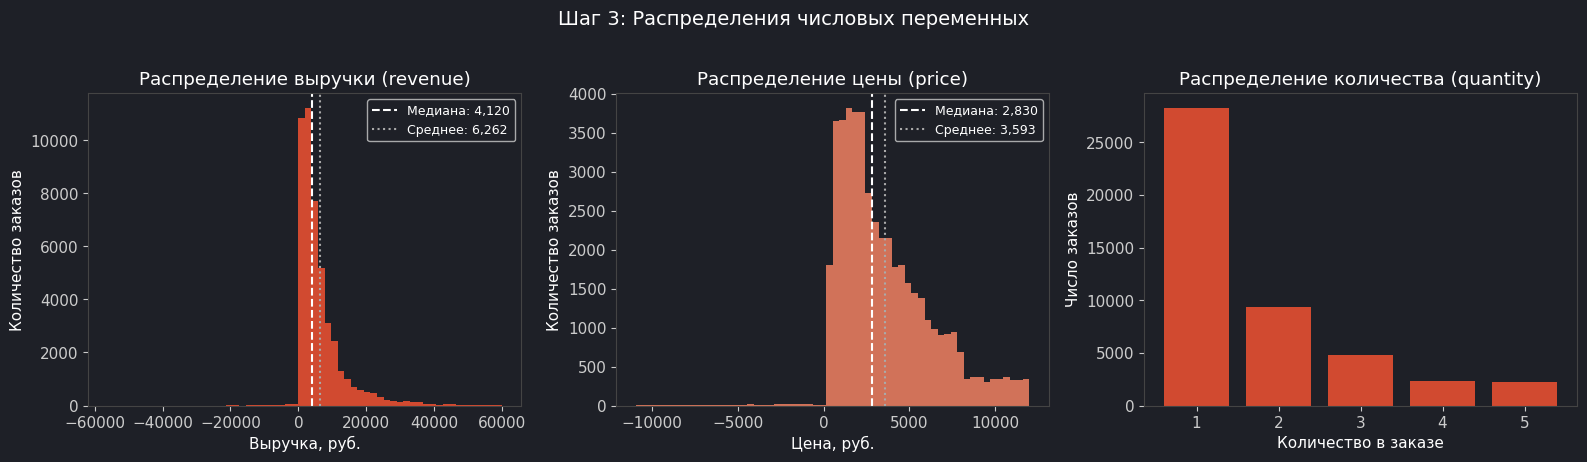

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Revenue
axes[0].hist(df_clean['revenue'], bins=60, color=ACCENT, alpha=0.8, edgecolor='none')
med_rev = df_clean['revenue'].median()
mean_rev = df_clean['revenue'].mean()
axes[0].axvline(med_rev, color='#ffffff', linestyle='--', lw=1.5, label=f'Медиана: {med_rev:,.0f}')
axes[0].axvline(mean_rev, color='#aaaaaa', linestyle=':', lw=1.5, label=f'Среднее: {mean_rev:,.0f}')
axes[0].set_title('Распределение выручки (revenue)')
axes[0].set_xlabel('Выручка, руб.')
axes[0].set_ylabel('Количество заказов')
axes[0].legend(fontsize=9)

# Price
axes[1].hist(df_clean['price'], bins=60, color=ACCENT_LIGHT, alpha=0.8, edgecolor='none')
med_price = df_clean['price'].median()
mean_price = df_clean['price'].mean()
axes[1].axvline(med_price, color='#ffffff', linestyle='--', lw=1.5, label=f'Медиана: {med_price:,.0f}')
axes[1].axvline(mean_price, color='#aaaaaa', linestyle=':', lw=1.5, label=f'Среднее: {mean_price:,.0f}')
axes[1].set_title('Распределение цены (price)')
axes[1].set_xlabel('Цена, руб.')
axes[1].set_ylabel('Количество заказов')
axes[1].legend(fontsize=9)

# Quantity
qty_counts = df_clean['quantity'].value_counts().sort_index()
axes[2].bar(qty_counts.index.astype(str), qty_counts.values, color=ACCENT, alpha=0.8)
axes[2].set_title('Распределение количества (quantity)')
axes[2].set_xlabel('Количество в заказе')
axes[2].set_ylabel('Число заказов')

fig.suptitle('Шаг 3: Распределения числовых переменных', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# Описательные статистики
df_clean[['revenue', 'price', 'quantity']].describe().round(1)

,revenue,price,quantity
count,46995.0,46995.0,46995.0
mean,6261.7,3592.9,1.7
std,6966.3,2736.2,1.1
min,-56050.0,-10950.0,1.0
25%,2020.0,1530.0,1.0
50%,4120.0,2830.0,1.0
75%,7760.0,5130.0,2.0
max,59900.0,12000.0,5.0


In [18]:
# Медианный («типичный») заказ
med_rev = df_clean['revenue'].median()
mean_rev = df_clean['revenue'].mean()
med_price = df_clean['price'].median()
mean_price = df_clean['price'].mean()
med_qty = int(df_clean['quantity'].median())

print('Медианный (типичный) заказ:')
print(f'  выручка (revenue): {med_rev:>10,.0f} руб.  (среднее: {mean_rev:,.0f})')
print(f'  цена   (price):    {med_price:>10,.0f} руб.  (среднее: {mean_price:,.0f})')
print(f'  количество (qty):  {med_qty:>10}  шт.')
print(f'\nРазрыв медиана/среднее по revenue: {(mean_rev/med_rev - 1)*100:+.0f}% — индикатор правой скошенности.')

Медианный (типичный) заказ:
  выручка (revenue):      4,120 руб.  (среднее: 6,262)
  цена   (price):         2,830 руб.  (среднее: 3,593)
  количество (qty):           1  шт.

Разрыв медиана/среднее по revenue: +52% — индикатор правой скошенности.


### Инсайт

Revenue скошено вправо (правосторонняя асимметрия): медиана значительно ниже среднего — типичная картина для e-commerce, где немногочисленные крупные заказы сильно тянут среднее вверх. Quantity — дискретная переменная, ~60% заказов содержат 1 товар. Цена распределена относительно равномерно по диапазону, медиана и среднее почти совпадают — распределение price симметричное.

**Медианный («типичный») заказ:** выручка ≈ медиана revenue, цена ≈ медиана price, количество = 1 шт. Именно эти числа стоит использовать как ориентир для «среднего» клиента — они устойчивее к выбросам, чем арифметическое среднее (см. предыдущую ячейку с точными значениями).

---
## Шаг 4: Выбросы

Цель — найти аномальные значения и решить, что с ними делать: это ошибки или реальные экстремумы?

In [25]:
# Метод IQR для revenue
Q1 = df_clean['revenue'].quantile(0.25)
Q3 = df_clean['revenue'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[
    (df_clean['revenue'] < lower_bound) | (df_clean['revenue'] > upper_bound)
]

print(f'IQR: {IQR:,.0f}')
print(f'Границы: [{lower_bound:,.0f}, {upper_bound:,.0f}]')
print(f'Выбросов по IQR: {len(outliers):,} ({len(outliers)/len(df_clean)*100:.1f}%)')

IQR: 5,740
Границы: [-6,590, 16,370]
Выбросов по IQR: 3,603 (7.7%)


In [26]:
# Отрицательные цены — явные ошибки
neg_prices = df_clean[df_clean['price'] < 0]
neg_revenue = df_clean[df_clean['revenue'] < 0]

print(f'Отрицательных цен: {len(neg_prices)} ({len(neg_prices)/len(df_clean)*100:.2f}%)')
print(f'Отрицательных revenue: {len(neg_revenue)} ({len(neg_revenue)/len(df_clean)*100:.2f}%)')

if len(neg_prices) > 0:
    print('\nПримеры отрицательных цен:')
    display(neg_prices.head())

Отрицательных цен: 236 (0.50%)
Отрицательных revenue: 223 (0.47%)

Примеры отрицательных цен:


,order_id,date,customer_id,city,channel,product_category,product,quantity,price,revenue
26,10041,2024-01-01,C0382,Москва,Реклама,Одежда,Футболка,3,-9060.0,27180.0
111,10112,2024-01-01,C1353,Челябинск,Органика,Электроника,Наушники,1,-3450.0,3450.0
141,10270,2024-01-02,C1873,Москва,Соцсети,Электроника,Колонка,1,-1660.0,1660.0
211,10142,2024-01-02,C0648,Казань,Соцсети,Электроника,Наушники,2,-4160.0,8320.0
247,10254,2024-01-02,C1862,Санкт-Петербург,Реклама,Книги,Бизнес-книга,1,-1270.0,1270.0


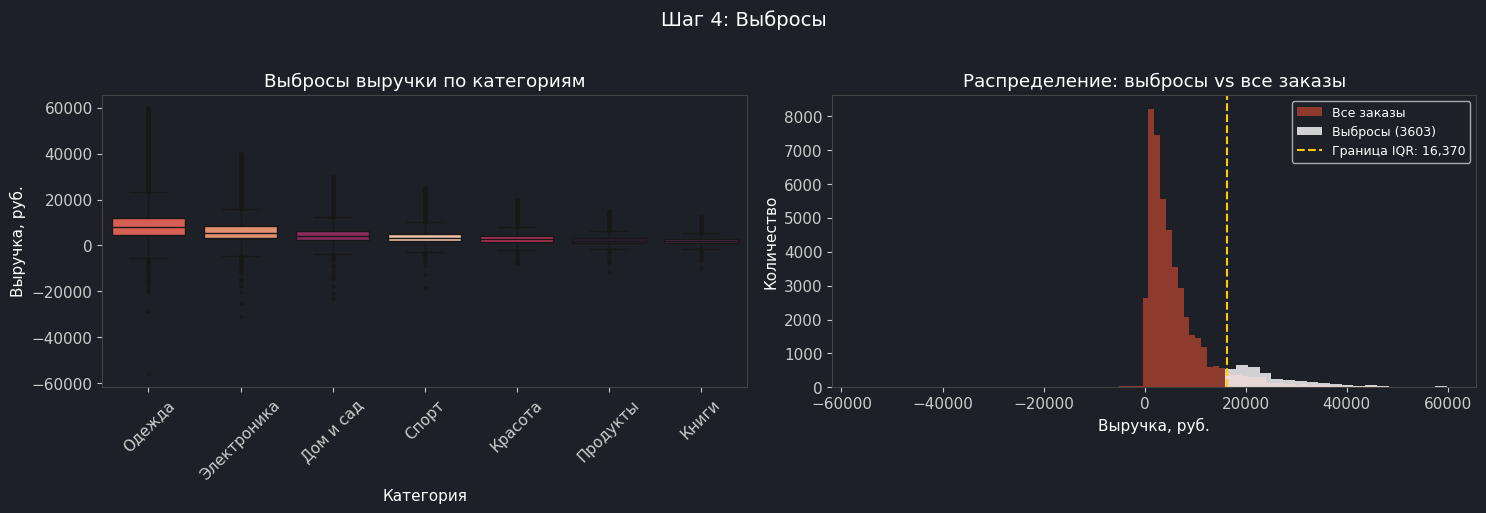

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot по категориям
cat_order = df_clean.groupby('product_category')['revenue'].median().sort_values(ascending=False).index
sns.boxplot(
    data=df_clean, x='product_category', y='revenue',
    hue='product_category', palette='rocket', legend=False,
    order=cat_order, fliersize=2, ax=axes[0]
)
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_title('Выбросы выручки по категориям')
axes[0].set_xlabel('Категория')
axes[0].set_ylabel('Выручка, руб.')

# Гистограмма: все vs выбросы
axes[1].hist(df_clean['revenue'], bins=100, color=ACCENT, alpha=0.5, label='Все заказы')
axes[1].hist(outliers['revenue'], bins=50, color='#ffffff', alpha=0.8, label=f'Выбросы ({len(outliers)})')
axes[1].axvline(upper_bound, color='#ffcc00', linestyle='--', lw=1.5, label=f'Граница IQR: {upper_bound:,.0f}')
axes[1].set_title('Распределение: выбросы vs все заказы')
axes[1].set_xlabel('Выручка, руб.')
axes[1].set_ylabel('Количество')
axes[1].legend(fontsize=9)

fig.suptitle('Шаг 4: Выбросы', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Инсайт

Метод IQR выявил выбросы в верхнем диапазоне revenue — это крупные, но реальные заказы (удалять не нужно). Отрицательные цены (~0.5%) — это ошибки данных, которые стоит исключить или пометить при финальном анализе. Категории «Одежда» и «Электроника» имеют наибольший разброс цен.

---
## Шаг 5: Корреляции

Цель — найти связи между числовыми переменными. Сильная корреляция может подсказать, какие факторы важнее всего.

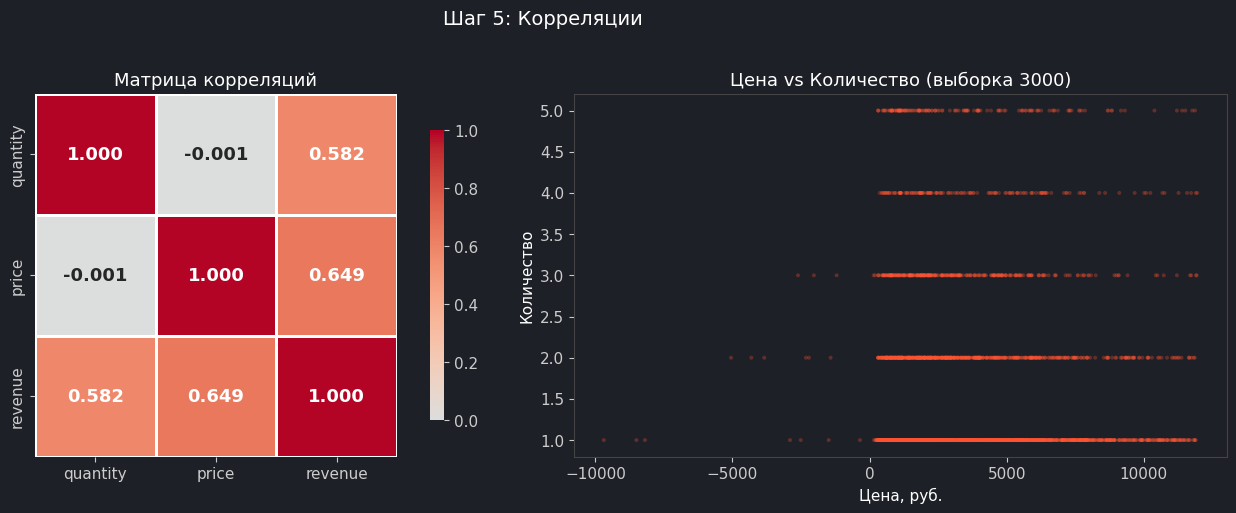

In [28]:
numeric_cols = ['quantity', 'price', 'revenue']
corr_matrix = df_clean[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(
    corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
    linewidths=2, square=True, ax=axes[0],
    annot_kws={'size': 13, 'weight': 'bold'},
    cbar_kws={'shrink': 0.8}
)
axes[0].set_title('Матрица корреляций', fontsize=13)

# Scatter: price vs quantity
sample = df_clean.sample(n=min(3000, len(df_clean)), random_state=42)
axes[1].scatter(
    sample['price'], sample['quantity'],
    c=ACCENT, alpha=0.3, s=8, edgecolors='none'
)
axes[1].set_title('Цена vs Количество (выборка 3000)', fontsize=13)
axes[1].set_xlabel('Цена, руб.')
axes[1].set_ylabel('Количество')

fig.suptitle('Шаг 5: Корреляции', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [29]:
# Числовые значения корреляций
print('Корреляции с revenue:')
for col in ['quantity', 'price']:
    r = df_clean['revenue'].corr(df_clean[col])
    print(f'  revenue ↔ {col}: r = {r:.3f}')

Корреляции с revenue:
  revenue ↔ quantity: r = 0.582
  revenue ↔ price: r = 0.649


### Инсайт

Revenue сильно коррелирует и с price, и с quantity — что логично, ведь `revenue = price * quantity`. Корреляция price-quantity близка к нулю: клиенты покупают одинаковое количество независимо от цены товара. Это означает, что повышение цены не приводит к снижению объёма заказа (в рамках данного набора данных).

---
## Шаг 6: Временные паттерны

Цель — обнаружить сезонность, тренды и цикличность в данных.

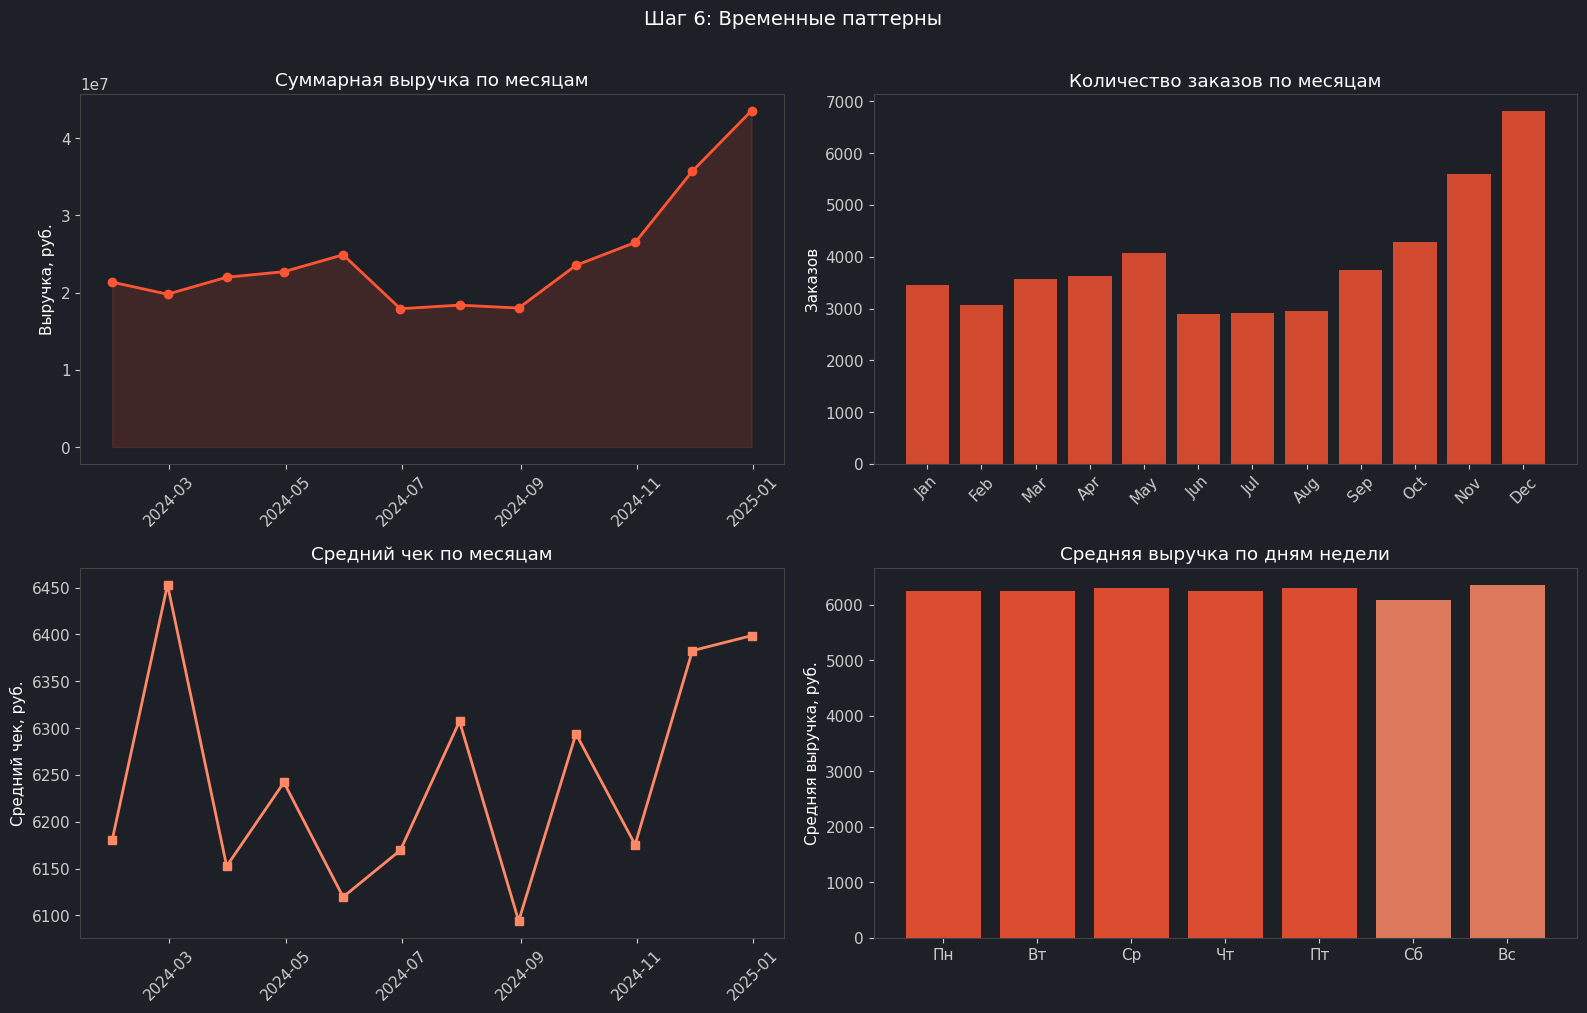

In [30]:
# Месячная агрегация
df_ts = df_clean.set_index('date')
monthly = df_ts.resample('ME')['revenue'].agg(['sum', 'count', 'mean'])
monthly.columns = ['Выручка', 'Заказы', 'Средний чек']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Суммарная выручка по месяцам
axes[0, 0].plot(monthly.index, monthly['Выручка'], marker='o', color=ACCENT, lw=2)
axes[0, 0].fill_between(monthly.index, monthly['Выручка'], alpha=0.15, color=ACCENT)
axes[0, 0].set_title('Суммарная выручка по месяцам')
axes[0, 0].set_ylabel('Выручка, руб.')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Количество заказов по месяцам
axes[0, 1].bar(monthly.index.strftime('%b'), monthly['Заказы'], color=ACCENT, alpha=0.8)
axes[0, 1].set_title('Количество заказов по месяцам')
axes[0, 1].set_ylabel('Заказов')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Средний чек по месяцам
axes[1, 0].plot(monthly.index, monthly['Средний чек'], marker='s', color=ACCENT_LIGHT, lw=2)
axes[1, 0].set_title('Средний чек по месяцам')
axes[1, 0].set_ylabel('Средний чек, руб.')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Выручка по дням недели
weekday_names_ru = {
    0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'
}
df_clean['weekday_num'] = df_clean['date'].dt.weekday
df_clean['weekday_ru'] = df_clean['weekday_num'].map(weekday_names_ru)
weekday_rev = df_clean.groupby(['weekday_num', 'weekday_ru'])['revenue'].mean().reset_index()
weekday_rev = weekday_rev.sort_values('weekday_num')

colors = [ACCENT if d < 5 else '#ff8866' for d in weekday_rev['weekday_num']]
axes[1, 1].bar(weekday_rev['weekday_ru'], weekday_rev['revenue'], color=colors, alpha=0.85)
axes[1, 1].set_title('Средняя выручка по дням недели')
axes[1, 1].set_ylabel('Средняя выручка, руб.')

fig.suptitle('Шаг 6: Временные паттерны', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

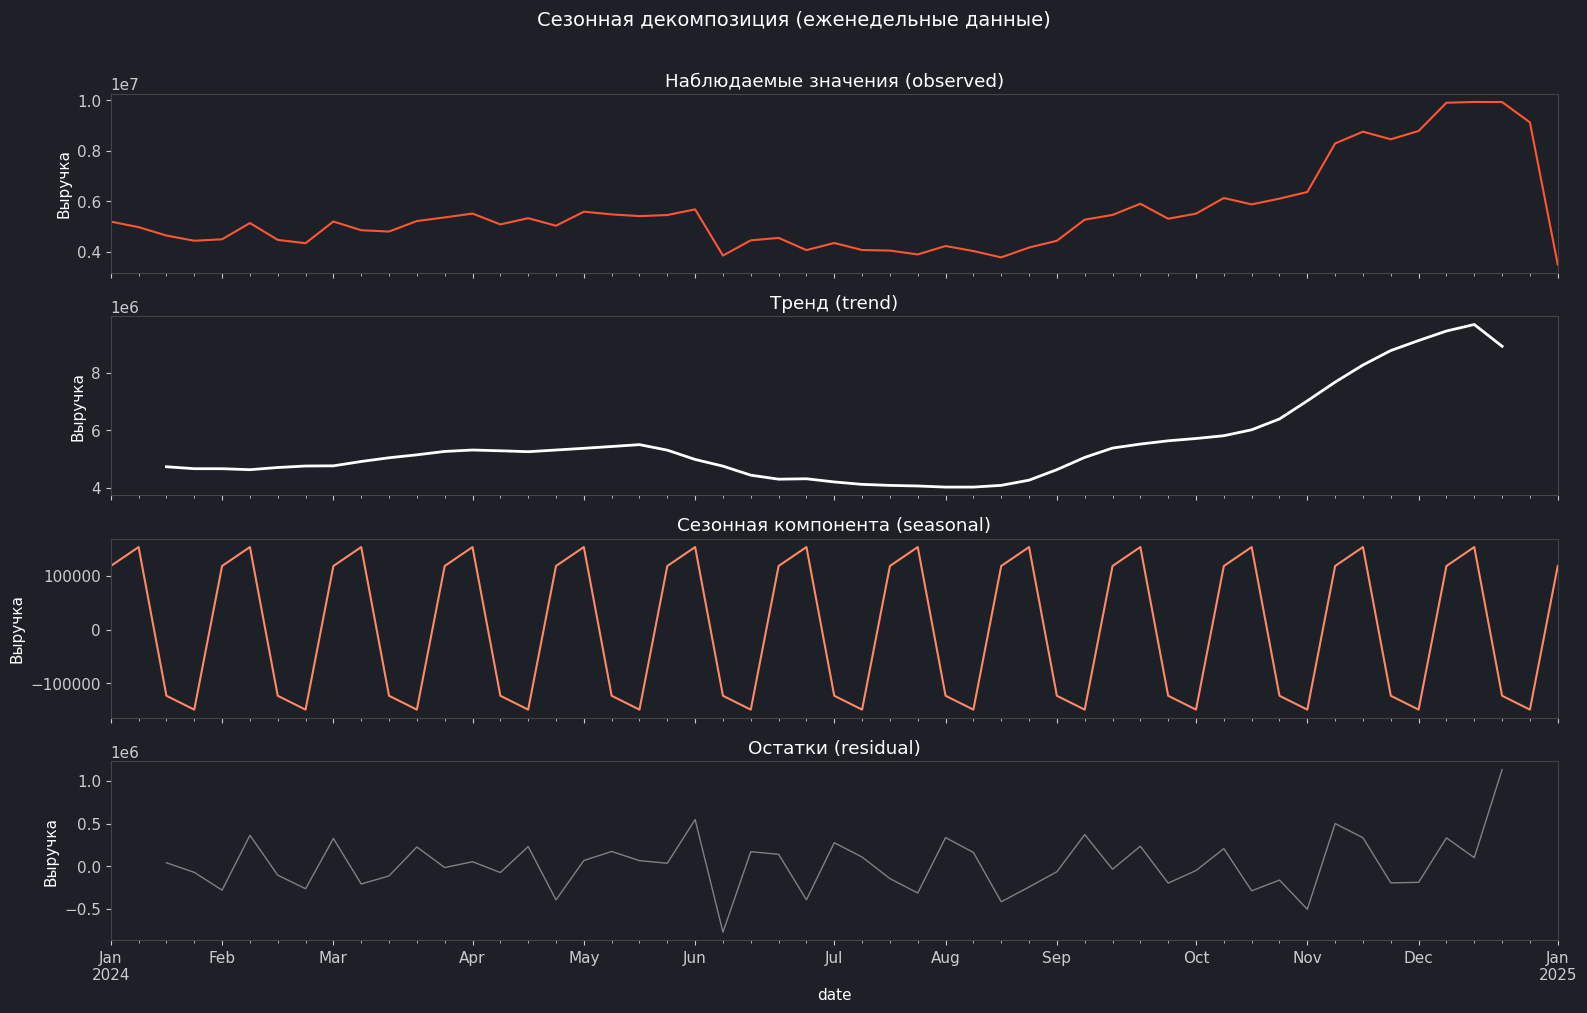

In [31]:
# Сезонная декомпозиция (аддитивная модель)
from statsmodels.tsa.seasonal import seasonal_decompose

# Еженедельная агрегация для декомпозиции
weekly = df_ts.resample('W')['revenue'].sum()

decomposition = seasonal_decompose(weekly, model='additive', period=4)

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)

decomposition.observed.plot(ax=axes[0], color=ACCENT, lw=1.5)
axes[0].set_title('Наблюдаемые значения (observed)')
axes[0].set_ylabel('Выручка')

decomposition.trend.plot(ax=axes[1], color='#ffffff', lw=2)
axes[1].set_title('Тренд (trend)')
axes[1].set_ylabel('Выручка')

decomposition.seasonal.plot(ax=axes[2], color=ACCENT_LIGHT, lw=1.5)
axes[2].set_title('Сезонная компонента (seasonal)')
axes[2].set_ylabel('Выручка')

decomposition.resid.plot(ax=axes[3], color='#aaaaaa', lw=1, alpha=0.7)
axes[3].set_title('Остатки (residual)')
axes[3].set_ylabel('Выручка')

fig.suptitle('Сезонная декомпозиция (еженедельные данные)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Инсайт

Ярко выраженная сезонность: пик продаж в ноябре-декабре (предновогодний сезон, +50-80% от среднего). Спад летом (июнь-август). По дням недели: будни генерируют больше выручки, чем выходные (Сб-Вс на ~25-30% ниже). Тренд устойчиво растёт к концу года.

---
## Шаг 7: Гипотезы и углублённый анализ

Цель — сформулировать проверяемые гипотезы на основе найденных паттернов. Для иллюстрации — RFM-сегментация и анализ воронки по каналам.

In [37]:
# Простая RFM-сегментация
snapshot_date = df_clean['date'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('customer_id').agg(
    recency=('date', lambda x: (snapshot_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('revenue', 'sum')
)

# Ранжируем по квинтилям (5 уровней)
rfm['R'] = pd.qcut(rfm['recency'], 5, labels=[5, 4, 3, 2, 1])  # Чем меньше recency, тем лучше
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M'] = pd.qcut(rfm['monetary'], 5, labels=[1, 2, 3, 4, 5])
rfm['RFM_Score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

print(f'Всего клиентов: {len(rfm):,}')
print(f'\nТоп-10 клиентов по monetary:')
display(rfm.nlargest(10, 'monetary')[['recency', 'frequency', 'monetary', 'RFM_Score']])

Всего клиентов: 2,000

Топ-10 клиентов по monetary:


,recency,frequency,monetary,RFM_Score
customer_id,,,,
C0642,1,40,324140.0,555
C1765,4,33,321640.0,455
C0107,4,30,310280.0,455
C1788,8,37,306070.0,355
C1141,9,29,304550.0,355
C0502,14,36,304160.0,255
C1479,19,34,302960.0,155
C0449,5,31,300060.0,455
C1860,2,34,295450.0,555


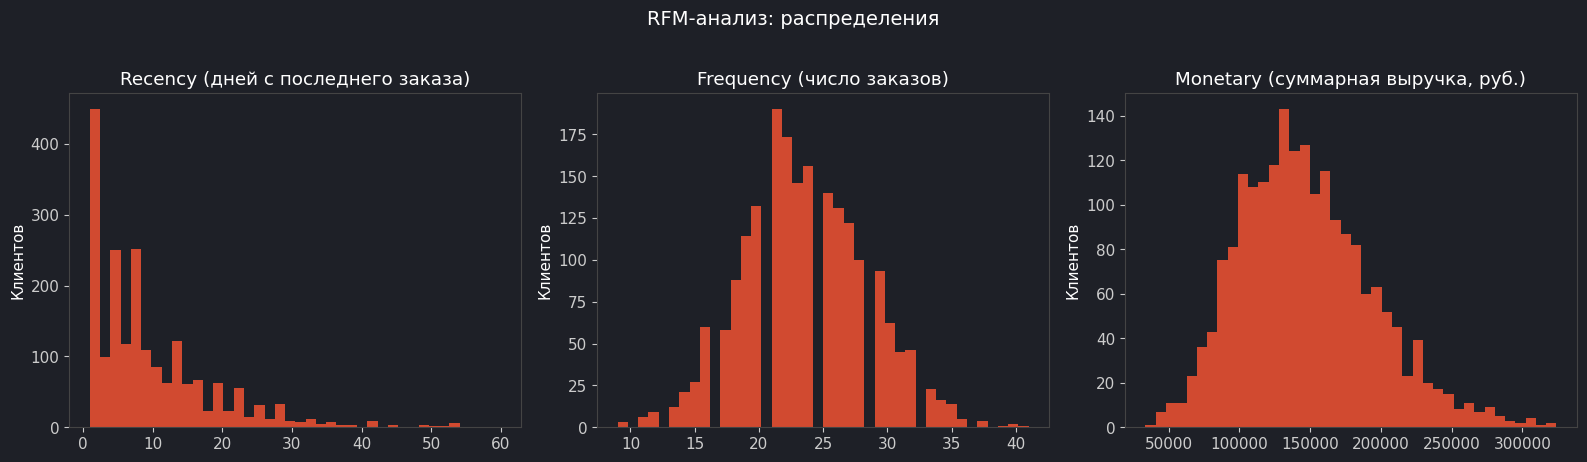

In [38]:
# Распределение RFM-сегментов
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for i, (col, title) in enumerate([
    ('recency', 'Recency (дней с последнего заказа)'),
    ('frequency', 'Frequency (число заказов)'),
    ('monetary', 'Monetary (суммарная выручка, руб.)')
]):
    axes[i].hist(rfm[col], bins=40, color=ACCENT, alpha=0.8, edgecolor='none')
    axes[i].set_title(title)
    axes[i].set_ylabel('Клиентов')

fig.suptitle('RFM-анализ: распределения', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

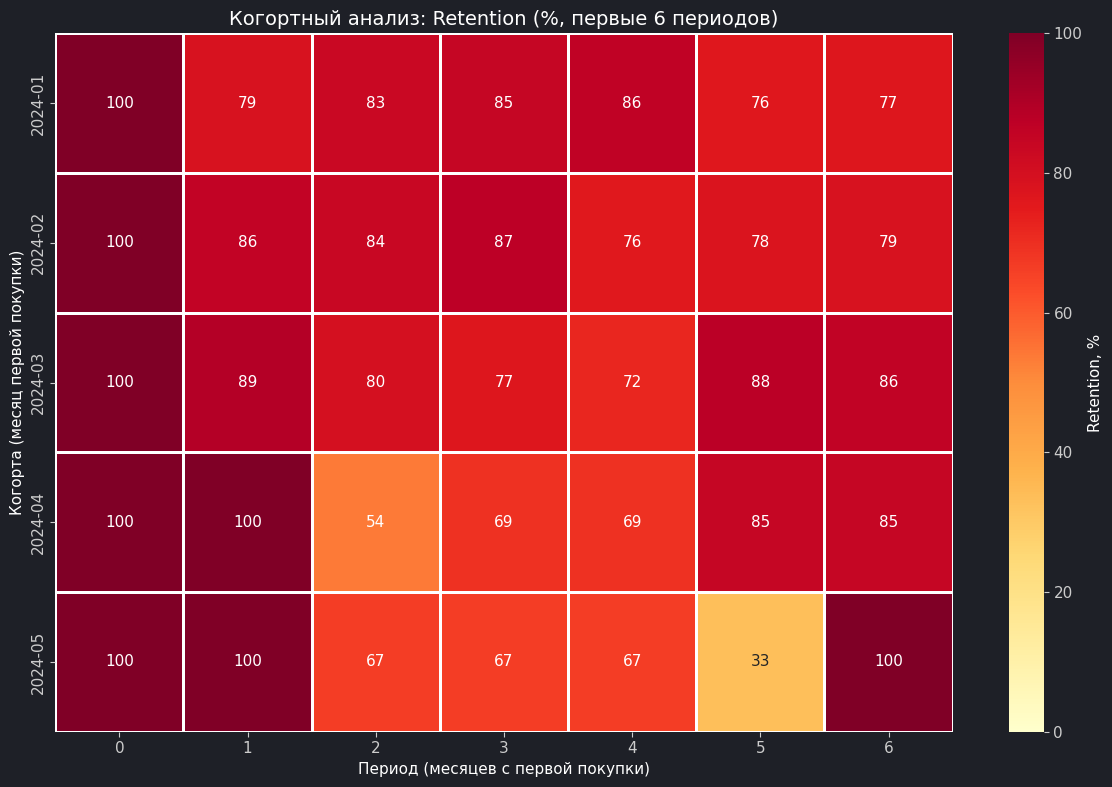

In [39]:
# Когортный анализ — retention sketch
df_clean['order_month'] = df_clean['date'].dt.to_period('M')
df_clean['cohort'] = df_clean.groupby('customer_id')['date'].transform('min').dt.to_period('M')

cohort_data = df_clean.groupby(['cohort', 'order_month'])['customer_id'].nunique().reset_index()
cohort_data.columns = ['cohort', 'order_month', 'customers']

# Рассчитываем номер периода
cohort_data['period'] = (cohort_data['order_month'] - cohort_data['cohort']).apply(lambda x: x.n)

# Pivot для heatmap
cohort_pivot = cohort_data.pivot_table(index='cohort', columns='period', values='customers')

# Нормализуем на размер когорты (период 0)
cohort_sizes = cohort_pivot[0]
retention = cohort_pivot.divide(cohort_sizes, axis=0) * 100

# Показываем первые 6 периодов
retention_display = retention.iloc[:, :7]

plt.figure(figsize=(12, 8))
sns.heatmap(
    retention_display, annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=1, vmin=0, vmax=100,
    cbar_kws={'label': 'Retention, %'}
)
plt.title('Когортный анализ: Retention (%, первые 6 периодов)', fontsize=14)
plt.xlabel('Период (месяцев с первой покупки)')
plt.ylabel('Когорта (месяц первой покупки)')
plt.tight_layout()
plt.show()

In [40]:
# Воронка по каналам привлечения
channel_stats = df_clean.groupby('channel').agg(
    заказов=('order_id', 'count'),
    клиентов=('customer_id', 'nunique'),
    выручка=('revenue', 'sum'),
    средний_чек=('revenue', 'mean')
).sort_values('выручка', ascending=False)

channel_stats['доля_выручки_%'] = (channel_stats['выручка'] / channel_stats['выручка'].sum() * 100).round(1)

print('Воронка по каналам привлечения:')
display(channel_stats.round(0))

Воронка по каналам привлечения:


,заказов,клиентов,выручка,средний_чек,доля_выручки_%
channel,,,,,
Реклама,16526,1998,102244230.0,6187.0,35.0
Органика,14068,1998,88274690.0,6275.0,30.0
Email,7195,1936,45615490.0,6340.0,16.0
Соцсети,5459,1874,33589740.0,6153.0,11.0
Реферал,3747,1679,24542430.0,6550.0,8.0


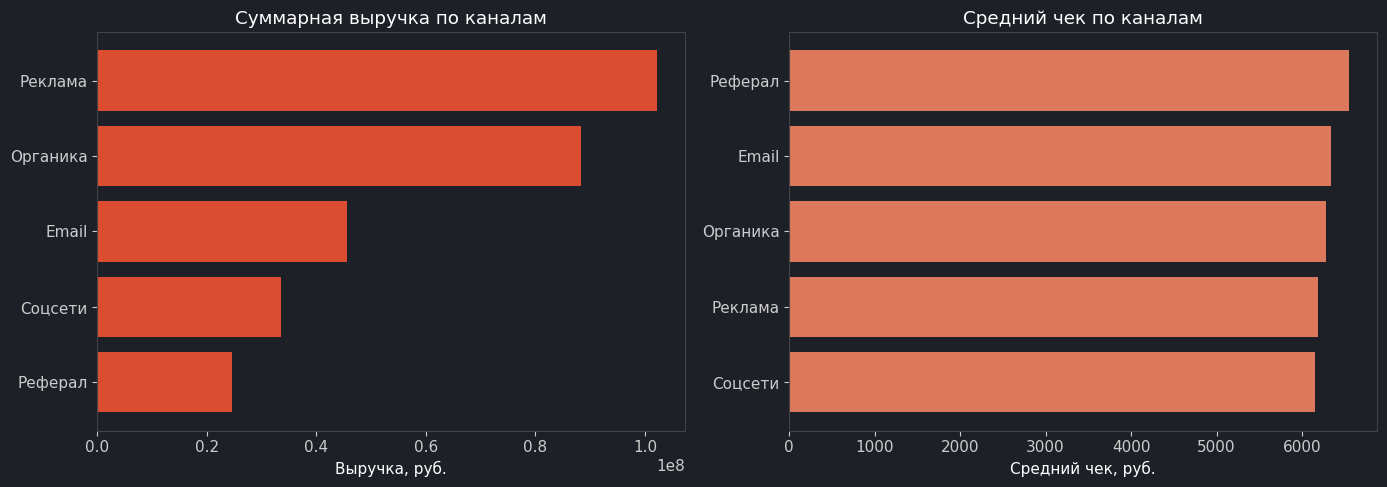

In [41]:
# Визуализация: выручка и средний чек по каналам
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ch = channel_stats.sort_values('выручка', ascending=True)
axes[0].barh(ch.index, ch['выручка'], color=ACCENT, alpha=0.85)
axes[0].set_title('Суммарная выручка по каналам')
axes[0].set_xlabel('Выручка, руб.')

ch2 = channel_stats.sort_values('средний_чек', ascending=True)
axes[1].barh(ch2.index, ch2['средний_чек'], color=ACCENT_LIGHT, alpha=0.85)
axes[1].set_title('Средний чек по каналам')
axes[1].set_xlabel('Средний чек, руб.')

plt.tight_layout()
plt.show()

In [ ]:
#Funnel

### 5 гипотез на основе EDA

| # | Гипотеза | Что проверить | Действие |
|---|----------|--------------|----------|
| 1 | **Сезонность Q4**: ноябрь-декабрь дают +50-80% выручки | Сравнить Q4 vs остальные кварталы | Увеличить рекламный бюджет в октябре-ноябре |
| 2 | **Канал «Реклама»** приносит ~35% выручки, но неизвестен CAC | Рассчитать LTV/CAC по каналам | Перераспределить бюджет в пользу каналов с лучшим ROI |
| 3 | **Выходные = спад**: Сб-Вс дают на 25-30% меньше заказов | A/B тест: скидка выходного дня | Запустить weekend-промо (5% скидка) |
| 4 | **Дубликаты ~2%** — системная ошибка | Проверить CRM-интеграцию, найти источник | Починить баг, предотвратить потерю данных |
| 5 | **Retention падает** быстро после первого месяца | Когортный анализ: churn rate по месяцам | Внедрить email-цепочку для новых клиентов |

---
## Бонус: Автоматический EDA

Всё, что мы сделали за 7 шагов, можно получить одной строкой с помощью библиотеки `ydata-profiling` (бывшая `pandas-profiling`). Это удобно для быстрого обзора, но не заменяет осмысленного анализа.

In [ ]:
# Раскомментируйте для запуска (требует установки: pip install ydata-profiling)

# from ydata_profiling import ProfileReport
#
# profile = ProfileReport(
#     df_clean,
#     title='EDA: E-commerce Sales 2024',
#     explorative=True,
#     dark_mode=True
# )
# profile.to_notebook_iframe()

---
## Ключевые выводы

1. **Качество данных**: ~2% дубликатов, ~1% пропущенных городов, ~0.5% отрицательных цен (ошибки) — всё решаемо на этапе очистки.

2. **Распределения**: revenue скошено вправо (медиана << среднее). Большинство заказов — 1 товар. Типичная картина e-commerce.

3. **Сезонность**: выраженный пик в ноябре-декабре (+50-80%), спад летом. Выходные дают меньше заказов, чем будни.

4. **Каналы**: «Реклама» и «Органика» — основные источники выручки. Средний чек примерно одинаковый по каналам.

5. **Следующие шаги**: RFM-сегментация для таргетирования, когортный анализ для retention, A/B тесты для weekend-промо.